# Dynamic conditional scale Beta-t-EGARCH model in Python

This self-contained notebook merges the Python translations of all four MATLAB files. Run the cells from top to bottom: the likelihood and filtering functions are defined before the estimation workflow, so no imports from separate project modules are required.


In [1]:
# Standard-library and scientific-computing dependencies
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
# Plotting packages are imported only inside the diagnostic functions.

# The notebook works when opened from either the repository root or Python Notebooks.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'Data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'Data'
RESULTS_DIR = PROJECT_ROOT / 'Results'


c:\Users\marco\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\marco\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Beta-t-EGARCH negative log-likelihood

This helper evaluates the objective used by the estimation notebook. It is a function, rather than a standalone analysis: call it through `f_s = @(x) Beta_univ_t_Egarch_Logl(x,Y,Inf_s,I_s)` and pass `f_s` to an optimizer.


## 0. Inputs and parameter conventions

`par` contains the location, long-run log scale, persistence, score loading, log degrees of freedom, and—when present—a leverage loading. `y` is a column vector of returns. `inf` selects information-standardized (`1`) or raw (`0`) scores; `I` selects the integrated (`1`) or stationary (`0`) scale recursion.

The degrees of freedom are parameterized as \(\nu=\exp(\texttt{vega\_l})\), which enforces positivity during optimization.


## 1. Filtering recursion

For each observation, the function computes the standardized residual \(e_t=(y_t-\mu)\exp(-\lambda_t)\), its Beta-type transform

$$B_t=\frac{e_t^2/\nu}{1+e_t^2/\nu},$$

and the Student's *t* score \(u_t=((\nu+1)B_t-1)/\mathcal I\). The next log scale follows either an integrated update or the mean-reverting AR(1) update, with an optional signed leverage contribution.


## 2. Objective returned to the optimizer

The last lines sum the conditional Student's *t* log densities and change the sign. Consequently, the function returns a **negative log-likelihood** suitable for minimization by `fmincon` or `fminsearch`.

## 3. Function implementation


## Python implementation

The code below is the Python translation of the MATLAB helper.


In [2]:
"""Negative log-likelihood for the Beta-t-EGARCH dynamic-scale model."""


def _unpack_parameters(par, I):
    """Translate the MATLAB parameter layouts into named Python values."""
    par = np.asarray(par, dtype=float).reshape(-1)
    kappa_2 = 0.0
    has_leverage = False

    if I == 1:
        if par.size not in (4, 5):
            raise ValueError("The integrated specification requires 4 or 5 parameters.")
        mu, omega, kappa, log_df = par[:4]
        phi = None
        if par.size == 5:
            kappa_2 = par[4]
            has_leverage = True
    else:
        if par.size not in (5, 6):
            raise ValueError("The stationary specification requires 5 or 6 parameters.")
        mu, omega, phi, kappa, log_df = par[:5]
        if par.size == 6:
            kappa_2 = par[5]
            has_leverage = True

    return mu, omega, phi, kappa, np.exp(log_df), kappa_2, has_leverage


def beta_t_egarch_filter(par, y, inf, I):
    """Filter log scale, standardized residuals, scores, and the Beta transform."""
    y = np.asarray(y, dtype=float).reshape(-1)
    mu, omega, phi, kappa, df, kappa_2, has_leverage = _unpack_parameters(par, I)
    n_obs = y.size
    lam = np.zeros(n_obs)
    res = np.zeros(n_obs)
    score = np.zeros(n_obs)
    beta = np.zeros(n_obs)
    information = 2 * df / (df + 3) if inf == 1 else 1.0
    next_lam = omega

    for index in range(n_obs):
        lam[index] = next_lam
        res[index] = (y[index] - mu) * np.exp(-lam[index])
        beta[index] = (res[index] ** 2 / df) / (1 + res[index] ** 2 / df)
        score[index] = ((df + 1) * beta[index] - 1) / information
        leverage = kappa_2 * np.sign(mu - y[index]) * (score[index] + 1) if has_leverage else 0.0
        if I == 1:
            next_lam = lam[index] + kappa * score[index] + leverage
        else:
            next_lam = omega * (1 - phi) + phi * lam[index] + kappa * score[index] + leverage

    return lam, res, score, beta


def beta_univ_t_egarch_logl(par, y, inf, I):
    """Return the negative Student's t log-likelihood, as in the MATLAB function."""
    _, _, _, _, df, _, _ = _unpack_parameters(par, I)
    lam, res, _, _ = beta_t_egarch_filter(par, y, inf, I)
    log_density_constant = gammaln((df + 1) / 2) - gammaln(df / 2) - 0.5 * np.log(np.pi * df)
    log_likelihood = (
        res.size * log_density_constant
        - np.sum(lam)
        - (df + 1) / 2 * np.sum(np.log1p(res ** 2 / df))
    )
    return -log_likelihood


# Beta-t-EGARCH likelihood with filtered quantities

This companion helper uses the same likelihood and state recursion as `Beta_univ_t_Egarch_Logl`, but additionally returns the filtered quantities needed for interpretation and diagnostics after estimation.


## 0. When to use this function

Call this function after estimation, using the fitted vector `x_s`. Its inputs have the same meanings as in the objective function, ensuring that fitted states are produced under precisely the specification that was optimized.


## 1. Returned objects

The function returns the negative log-likelihood `Logl`, the log-scale path `lam`, standardized residuals `res`, score innovations `u`, and the Beta-type transformation `Beta`. These series underpin the fitted-scale, residual-density, autocorrelation, and PIT diagnostics in the main notebook.

The legacy `fit` output is retained as `y - res` for compatibility with the original workflow.


## 2. Filtering logic

At each date, the current state determines the conditional scale; the standardized residual generates a Student's *t* score; and that score updates the next state. The code therefore produces one-step-ahead filtered quantities in chronological order.

## 3. Function implementation


## Python implementation

The code below is the Python translation of the MATLAB helper.


In [3]:
"""Beta-t-EGARCH likelihood together with filtered diagnostic quantities."""


def beta_univ_t_egarch_logl_fact(par, y, inf, I):
    """Return negative log-likelihood, scale path, residuals, scores, Beta, and fit."""
    y = np.asarray(y, dtype=float).reshape(-1)
    _, _, _, _, df, _, _ = _unpack_parameters(par, I)
    lam, res, score, beta = beta_t_egarch_filter(par, y, inf, I)
    fit = y - res  # Legacy MATLAB output, kept for compatibility.
    log_density_constant = gammaln((df + 1) / 2) - gammaln(df / 2) - 0.5 * np.log(np.pi * df)
    log_likelihood = (
        y.size * log_density_constant
        - np.sum(lam)
        - (df + 1) / 2 * np.sum(np.log1p(res ** 2 / df))
    )
    return -log_likelihood, lam, res, score, beta, fit


# Information criteria for model comparison

This small helper computes the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) from a likelihood value, a parameter vector, and the sample size.


## 0. Interpretation

The function applies

$$\mathrm{AIC}=2k-2\ell, \qquad \mathrm{BIC}=k\log(n)-2\ell,$$

where \(k\) is the number of estimated parameters, \(n\) is the sample size, and \(\ell\) is the likelihood quantity supplied by the calling code. When models are evaluated under a common likelihood convention and on the same sample, lower values are preferred.

## 1. Function implementation


## Python implementation

The code below is the Python translation of the MATLAB helper.


In [4]:
"""Information criteria used by the DCSt model."""


def info_crit(logl, par, n):
    """Return BIC and AIC using the likelihood convention supplied by the caller."""
    n_parameters = np.asarray(par).size
    bic = -2 * logl + n_parameters * np.log(n)
    aic = 2 * n_parameters - 2 * logl
    return bic, aic


## Main dynamic-scale modelling workflow

The remaining cells replace the former all-in-one workflow function. Run them in order: each cell produces named objects used by the next stage, making the estimation and diagnostics easier to inspect or adapt.


### 1. Load prices and form log returns

The model is estimated on continuously compounded returns, calculated as the log ratio of consecutive closing prices. Change `filename` to analyse another series in the `Data` folder.


In [5]:
def load_log_returns(filename="NSX Close---.xlsx"):
    """Load one price series and convert consecutive prices into log returns."""
    prices = pd.read_excel(DATA_DIR / filename, header=None).to_numpy(dtype=float).reshape(-1)
    return np.log(prices[1:] / prices[:-1])


filename = "NSX Close---.xlsx"
y = load_log_returns(filename)
print(f"Loaded {y.size:,} log returns from {filename}.")


Loaded 7,709 log returns from NSX Close---.xlsx.


### 2. Choose the model specification and starting values

These switches preserve the MATLAB specification: a non-integrated scale dynamics with information and leverage terms, constrained parameters, and a small common starting value.


In [6]:
def initial_parameters(y, integrated, leverage, constrained, kappa_start):
    """Construct the original MATLAB starting values and parameter bounds."""
    if integrated:
        size = 5 if leverage else 4
        start = np.full(size, kappa_start)
        start[0], start[1], start[3] = np.mean(y), np.log(np.std(y, ddof=1)), np.log(8)
        lower, upper = np.full(size, -np.inf), np.full(size, np.inf)
        lower[2] = 0
    else:
        size = 6 if leverage else 5
        start = np.full(size, kappa_start)
        start[0], start[1], start[2], start[4] = np.mean(y), np.log(np.std(y, ddof=1)), 0.9, np.log(8)
        lower, upper = np.full(size, -np.inf), np.full(size, np.inf)
        lower[2], lower[3], upper[2] = 0, 0, 1
    return start, list(zip(lower, upper)) if constrained else None


integrated_scale, information_scale, leverage_scale = 0, 1, 1
constrained_scale, kappa_start = 1, 0.01
start, bounds = initial_parameters(
    y, integrated_scale, leverage_scale, constrained_scale, kappa_start
)
pd.DataFrame({"starting value": start, "lower/upper bound": bounds})


,starting value,lower/upper bound
0,0.000474,"(-inf, inf)"
1,-4.078820,"(-inf, inf)"
2,0.900000,"(0.0, 1.0)"
3,0.010000,"(0.0, inf)"
4,2.079442,"(-inf, inf)"
5,0.010000,"(-inf, inf)"


### 3. Inspect the unconditional return series

This reproduces the original distribution, autocorrelation, and Gaussian Q-Q diagnostics before fitting the conditional-scale model.


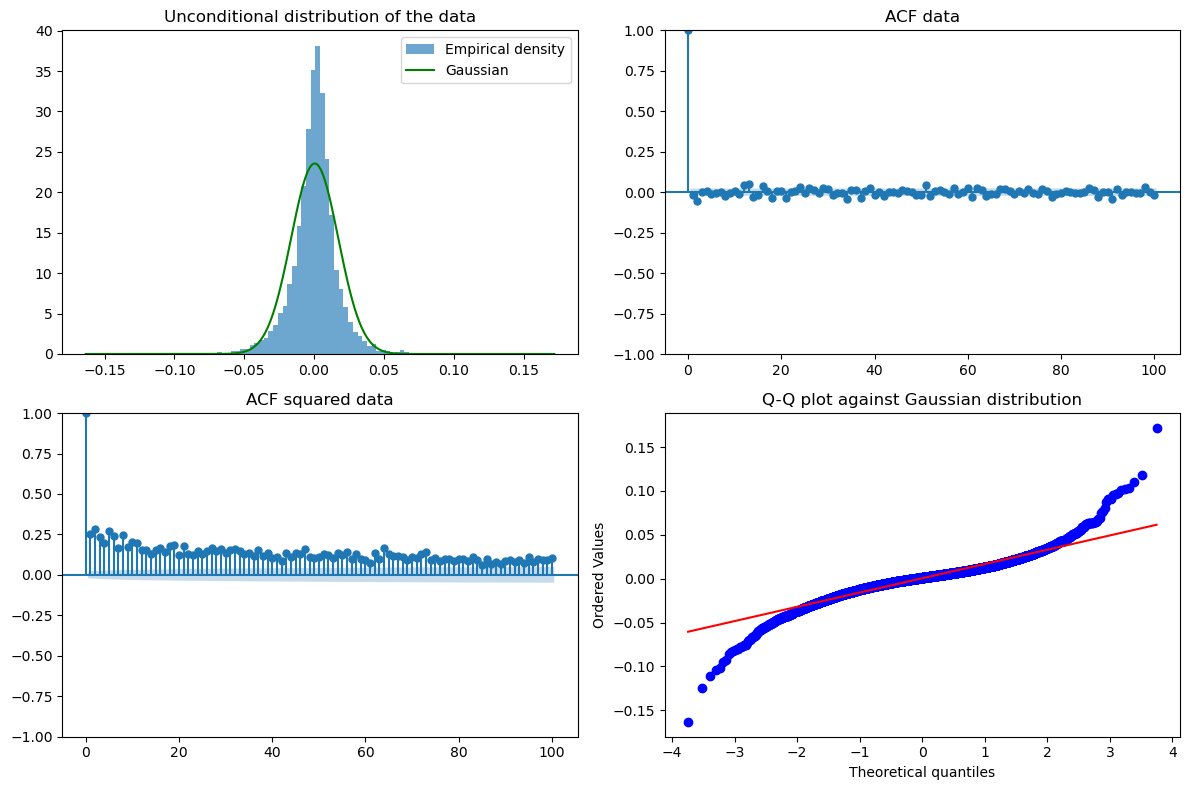

In [7]:
from matplotlib import pyplot as plt
from scipy.stats import norm, probplot
from statsmodels.graphics.tsaplots import plot_acf

grid = np.linspace(np.min(y), np.max(y), 1000)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(y, bins=100, density=True, alpha=0.65, label="Empirical density")
axes[0, 0].plot(grid, norm.pdf(grid, np.mean(y), np.std(y, ddof=1)), "g-", label="Gaussian")
axes[0, 0].set_title("Unconditional distribution of the data"); axes[0, 0].legend()
plot_acf(y, lags=100, ax=axes[0, 1]); axes[0, 1].set_title("ACF data")
plot_acf(y ** 2, lags=100, ax=axes[1, 0]); axes[1, 0].set_title("ACF squared data")
probplot(y, dist="norm", plot=axes[1, 1]); axes[1, 1].set_title("Q-Q plot against Gaussian distribution")
fig.tight_layout()


### 4. Estimate the Beta-t-EGARCH parameters

The optimizer minimizes the negative log-likelihood defined above. `maxiter` can be lowered for a quick check; retain the original value for the full estimation. The fitted parameters are also saved in `Results/estPar_Python.xlsx`.


In [8]:
maxiter = 67_000
objective = lambda par: beta_univ_t_egarch_logl(
    par, y, information_scale, integrated_scale
)
optimization = minimize(
    objective, start, method="L-BFGS-B", bounds=bounds, options={"maxiter": maxiter}
)
if not optimization.success:
    print(f"Optimizer message: {optimization.message}")

par_hat = optimization.x
RESULTS_DIR.mkdir(exist_ok=True)
pd.DataFrame({"estimate": par_hat}).to_excel(
    RESULTS_DIR / "estPar_Python.xlsx", index=False
)
print(f"Converged: {optimization.success}; objective value: {optimization.fun:.6f}")
pd.DataFrame({"estimate": par_hat})


Converged: True; objective value: -22383.645845


C:\Users\marco\AppData\Local\Temp\ipykernel_2316\89194805.py:13: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  pd.DataFrame({"estimate": par_hat}).to_excel(


,estimate
0,0.000806
1,-4.531853
2,0.988852
3,0.059330
4,2.153980
5,0.027585


### 5. Recover fitted quantities and information criteria

The filtering helper returns the conditional log-scale, standardized residuals, score, Beta coefficients, and fitted series. BIC and AIC summarize the in-sample fit.


In [9]:
logl, lam, res, score, beta, fit = beta_univ_t_egarch_logl_fact(
    par_hat, y, information_scale, integrated_scale
)
bic, aic = info_crit(logl, par_hat, y.size)
mu = par_hat[0]
df = np.exp(par_hat[3] if integrated_scale else par_hat[4])

fit_summary = pd.Series(
    {"log likelihood": logl, "BIC": bic, "AIC": aic, "degrees of freedom": df}
)
fit_summary


log likelihood       -22383.645845
BIC                   44820.992552
AIC                   44779.291690
degrees of freedom        8.619095
dtype: float64

### 6. Compare returns with the fitted conditional scale

The conditional scale is plotted against both demeaned returns and their absolute values. This shows where the model identifies periods of higher or lower volatility.


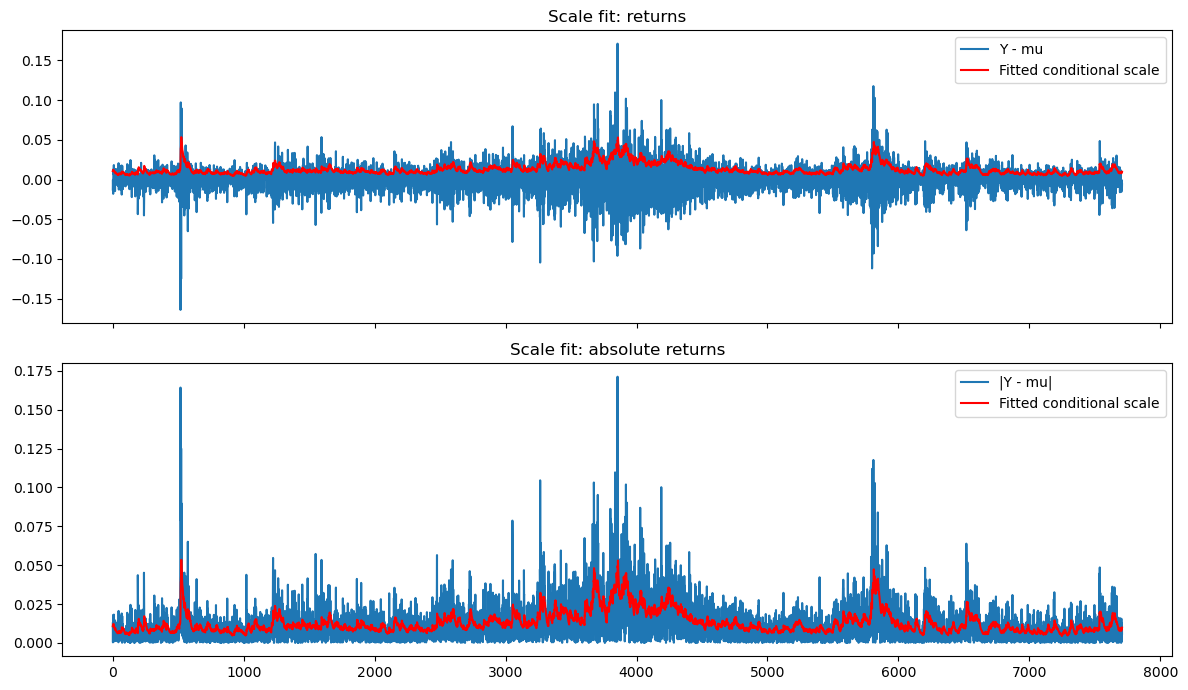

In [10]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(y - mu, label="Y - mu")
axes[0].plot(np.exp(lam), "r", label="Fitted conditional scale")
axes[0].set_title("Scale fit: returns"); axes[0].legend()
axes[1].plot(np.abs(y - mu), label="|Y - mu|")
axes[1].plot(np.exp(lam), "r", label="Fitted conditional scale")
axes[1].set_title("Scale fit: absolute returns"); axes[1].legend()
fig.tight_layout()


### 7. Check the fitted residual distribution

Standardized residuals should be comparable with the fitted Student-t distribution. The Gaussian curve is retained as the original benchmark.


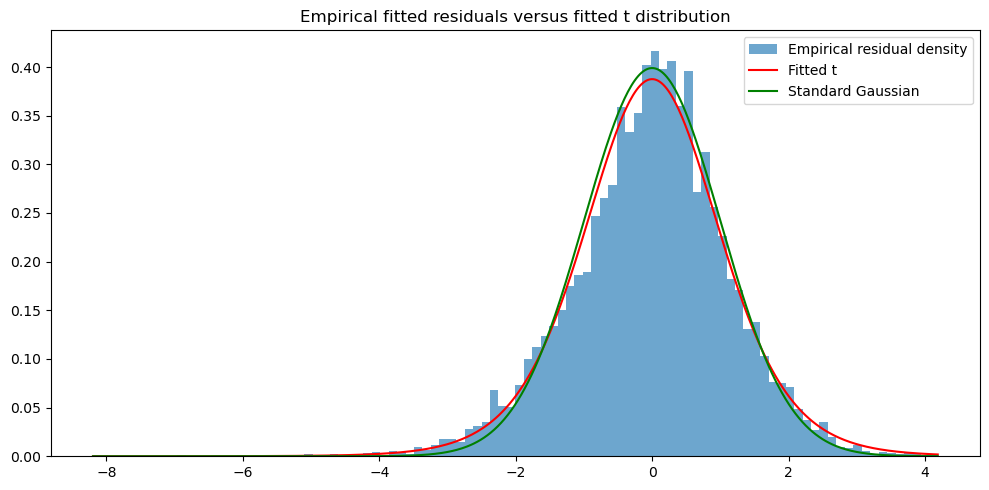

In [11]:
from matplotlib import pyplot as plt
from scipy.stats import norm, t as student_t

grid = np.linspace(np.min(res), np.max(res), 500)
plt.figure(figsize=(10, 5))
plt.hist(res, bins=100, density=True, alpha=0.65, label="Empirical residual density")
plt.plot(grid, student_t.pdf(grid, df), "r-", label="Fitted t")
plt.plot(grid, norm.pdf(grid), "g-", label="Standard Gaussian")
plt.title("Empirical fitted residuals versus fitted t distribution")
plt.legend(); plt.tight_layout()


### 8. Check residual and score autocorrelation

Autocorrelation in residuals, squared residuals, or fitted scores can reveal dynamics that the fitted model has not captured.


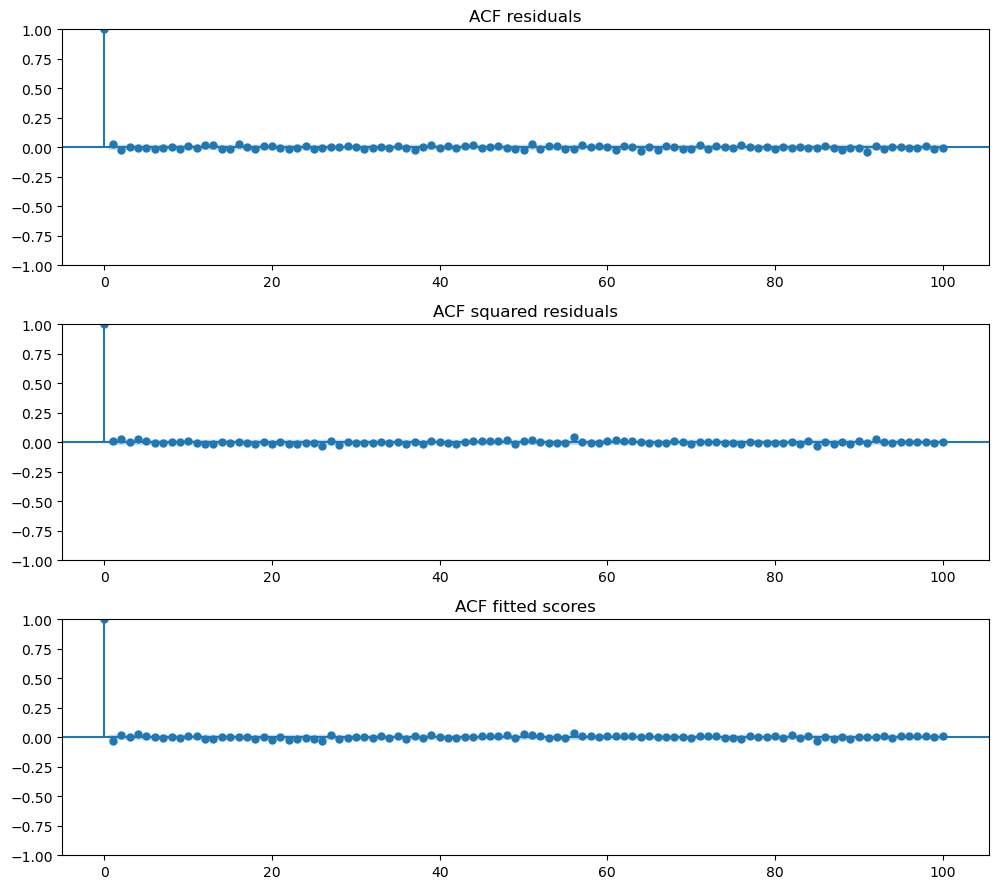

In [12]:
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(3, 1, figsize=(10, 9))
plot_acf(res, lags=100, ax=axes[0]); axes[0].set_title("ACF residuals")
plot_acf(res ** 2, lags=100, ax=axes[1]); axes[1].set_title("ACF squared residuals")
plot_acf(score, lags=100, ax=axes[2]); axes[2].set_title("ACF fitted scores")
fig.tight_layout()


### 9. Inspect the probability-integral transform

For a well-calibrated conditional distribution, the ordered probability-integral transform (PIT) should approximately follow the diagonal uniform benchmark.


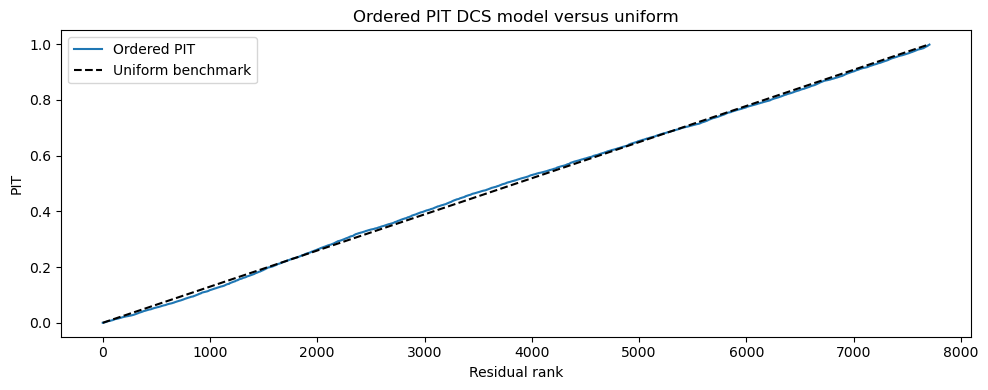

In [13]:
from matplotlib import pyplot as plt
from scipy.stats import t as student_t

pit = student_t.cdf(np.sort(res), df)
plt.figure(figsize=(10, 4))
plt.plot(pit, label="Ordered PIT")
plt.plot(np.linspace(0, 1, pit.size), "k--", label="Uniform benchmark")
plt.title("Ordered PIT DCS model versus uniform")
plt.xlabel("Residual rank"); plt.ylabel("PIT")
plt.legend(); plt.tight_layout()
